# Tutorial 3: Protein Embeddings

This notebook demonstrates how to compute **protein-level embeddings** with
`embpy`, annotate proteins with rich biological metadata, and compare
embeddings across models and proteins using `embpy`'s visualization toolkit.

## Available protein embedding models

| Model key | Parameters | Architecture | Notes |
|---|---|---|---|
| `esm1b` | 650 M | ESM-1b | Original ESM protein LM |
| `esm1v_1` -- `esm1v_5` | 650 M | ESM-1v | 5 variant-prediction heads |
| `esm2_8M` | 8 M | ESM-2 | Fastest, lowest quality |
| `esm2_35M` | 35 M | ESM-2 | |
| `esm2_150M` | 150 M | ESM-2 | |
| `esm2_650M` | 650 M | ESM-2 | Good quality/speed tradeoff |
| `esm2_3B` | 3 B | ESM-2 | High quality |
| `esm2_15B` | 15 B | ESM-2 | Highest quality ESM-2 |
| `esmc_300m` | 300 M | ESM-C | Latest EvolutionaryScale architecture |
| `esmc_600m` | 600 M | ESM-C | |
| `esmc_6b` | 6 B | ESM-C | Largest ESM-C |
| `esm3_small` | small | ESM-3 | Multi-track (seq + structure + function) |
| `esm3_medium` | medium | ESM-3 | |
| `esm3_large` | large | ESM-3 | |
| `prot_t5_xl` | 3 B | ProtT5 | T5-based protein LM (Rostlab) |
| `prot_t5_xl_half` | 3 B | ProtT5 | Half-precision (lower memory) |
| `boltz2` | -- | Boltz-2 | Structure-aware single-chain repr. |
| `boltz2_pairwise` | -- | Boltz-2 | Pairwise residue representation |
| `boltz2_both` | -- | Boltz-2 | Single + pairwise combined |

All models take amino-acid sequences as input. `BioEmbedder` will
automatically fetch protein sequences from UniProt when you provide a
gene symbol or Ensembl ID.

### What this tutorial covers

1. Single and batch protein embedding (ESM-2)
2. Raw sequence embedding and pooling strategies
3. Canonical vs. isoform protein embeddings
4. Additional model families: ESM-3, ProtT5, Boltz-2
5. **Rich protein annotations** with `ProteinAnnotator` (domains, GO terms, PTMs, disease, function, subcellular location)
6. **Multi-protein cross-model comparison** with AnnData
7. **Visualizations**: similarity heatmaps, UMAP colored by annotations, cross-model agreement, dendrograms
8. **Weighted protein embeddings**: annotation-weighted pooling, TPM-weighted isoform averaging, expression-context embeddings

## Start here: standardized embedding outputs

The primary user-facing path for new embedding work is now `BioEmbedder.embed(...)`. It normalizes direct inputs and CSV/TSV/Parquet paths, canonicalizes identifiers by entity type, and routes results to either AnnData or a table.

Key contract:

- genes use Ensembl gene IDs, molecules use canonical SMILES, proteins use UniProt accessions
- aliases such as symbols, names, or original user inputs are kept as metadata/columns
- generated embeddings never go into AnnData `.X`; they go to `.obsm`, `.varm`, or `.uns`
- standalone AnnData uses sparse placeholder `.X` only
- table output defaults to Parquet plus a `.meta.json` sidecar
- `harmonize_dim=...` applies per-result PCA before export and records provenance

The older model-specific examples below are still useful for lower-level control. Treat this section as the standard output shape to prefer when building pipelines or sharing results.


In [ ]:
from embpy import BioEmbedder

RUN_STANDARDIZED_EMBED_DEMO = False

if RUN_STANDARDIZED_EMBED_DEMO:
    embedder = BioEmbedder(device="auto", organism="human")

    protein_adata = embedder.embed(
        ["TP53", "EGFR", "KRAS"],
        entity_type="protein",
        model="esm2_650M",
        output="anndata",
        harmonize_dim=32,
    )
    print(protein_adata)
    print(protein_adata.varm.keys())  # protein/gene-level embeddings use .varm

    # Variable-length isoform outputs are stored as structured .uns payloads.
    isoforms = embedder.embed(
        ["TP53"],
        entity_type="protein",
        model="esm2_650M",
        output="anndata",
        isoform="all",
    )
    print(isoforms.uns.keys())

In [1]:
import logging
import warnings

logging.basicConfig(level=logging.WARNING)
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=".*truncate to max_length.*")

In [2]:
from embpy.embedder import BioEmbedder

embedder = BioEmbedder(device="auto")
print(f"Device: {embedder.device}")

Device: cuda


## 1. Embed a single gene as a protein

The `embed_gene` method detects that you are using a protein model and
will fetch the corresponding amino-acid sequence automatically.

In [3]:
MODEL = "esm2_650M"  # good balance of quality and speed

emb = embedder.embed_gene(
    identifier="TP53",
    model=MODEL,
    id_type="symbol",
    organism="human",
    pooling_strategy="mean",
)

print(f"Shape:  {emb.shape}")
print(f"Dtype:  {emb.dtype}")
print(f"Norm:   {(emb**2).sum() ** 0.5:.2f}")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Shape:  (1280,)
Dtype:  float32
Norm:   8.24


## 2. Provide a raw protein sequence

If you already have the amino-acid sequence, pass it directly. The
identifier detector will recognize it as a protein sequence.

In [4]:
# First 100 residues of human p53 (UniProt P04637)
p53_frag = "MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGPDEAPRMPEAAPPVAPAPAAPTPAAPAPAPSWPLSSSVPSQK"

emb_seq = embedder.embed_gene(
    identifier=p53_frag,
    model=MODEL,
    id_type="sequence",
    pooling_strategy="mean",
)
print(f"Fragment embedding shape: {emb_seq.shape}")

Fragment embedding shape: (1280,)


## 3. Batch protein embedding

In [5]:
genes = ["TP53", "BRCA1", "EGFR", "KRAS", "MYC"]

embeddings = embedder.embed_genes_batch(
    model=MODEL,
    identifiers=genes,
    id_type="symbol",
    organism="human",
    pooling_strategy="mean",
)

for gene, emb in zip(genes, embeddings, strict=False):
    if emb is not None:
        print(f"  {gene:8s} → dim {emb.shape[0]:,}")
    else:
        print(f"  {gene:8s} → FAILED")

  TP53     → dim 1,280
  BRCA1    → dim 1,280
  EGFR     → dim 1,280
  KRAS     → dim 1,280
  MYC      → dim 1,280


## 4. Comparing ESM-2 model sizes

Larger ESM-2 checkpoints produce higher-quality but higher-dimensional
embeddings. Here we compare the output dimensionality.

In [6]:
for m in ["esm2_8M", "esm2_35M", "esm2_150M", "esm2_650M"]:
    try:
        e = embedder.embed_gene("TP53", model=m, pooling_strategy="mean")
        print(f"  {m:15s} → dim {e.shape[0]:,}")
    except Exception as exc:
        print(f"  {m:15s} → {exc}")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


  esm2_8M         → dim 320


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


  esm2_35M        → dim 480


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


  esm2_150M       → dim 640
  esm2_650M       → dim 1,280


## 5. Pooling strategies for protein models

Protein language models output one vector per residue. Pooling reduces
these to a single vector:

- `"mean"` – average across residues (most common)
- `"max"` – max-pool across residues
- `"cls"` – use the CLS token embedding

In [7]:
import numpy as np

for strategy in ["mean", "max", "cls"]:
    try:
        e = embedder.embed_gene("TP53", model=MODEL, pooling_strategy=strategy)
        print(f"  {strategy:5s} → shape {e.shape}, L2 norm = {np.linalg.norm(e):.2f}")
    except Exception as exc:
        print(f"  {strategy:5s} → {exc}")

  mean  → shape (1280,), L2 norm = 8.24
  max   → shape (1280,), L2 norm = 18.24
  cls   → shape (1280,), L2 norm = 10.07


## 6. Fetching protein sequences separately

You can also use the `GeneResolver` to fetch protein sequences first,
inspect or filter them, and then embed.

In [8]:
from embpy.resources.gene import GeneResolver

resolver = GeneResolver(auto_download=False)

seq = resolver.get_protein_sequence("BRCA1", id_type="symbol")
if seq:
    print(f"BRCA1 protein length: {len(seq)} aa")
    print(f"First 80 aa: {seq[:80]}…")

BRCA1 protein length: 1863 aa
First 80 aa: MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKFCMLKLLNQKKGPSQCPLCKNDITKRSLQESTRFS…


In [9]:
# Batch fetch protein sequences
prot_seqs = resolver.get_protein_sequences_batch(
    ["TP53", "BRCA1", "EGFR"],
    id_type="symbol",
)
for gene_id, seq in prot_seqs.items():
    print(f"  {gene_id:8s} → {len(seq):,} aa")

  TP53     → 393 aa
  BRCA1    → 1,863 aa
  EGFR     → 1,210 aa


## 7. Using ESM-C models

ESM-C is a more recent architecture from EvolutionaryScale.
Usage is identical.

In [10]:
try:
    emb_esmc = embedder.embed_gene(
        "TP53",
        model="esmc_300m",
        pooling_strategy="mean",
    )
    print(f"ESM-C 300M embedding: shape {emb_esmc.shape}")
except Exception as exc:
    print(f"ESM-C not available: {exc}")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

/ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/.pixi/envs/gpu/lib/python3.12/site-packages/esm/pretrained.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dic

ESM-C 300M embedding: shape (960,)


## 8. Canonical vs Isoform Protein Embeddings

The `embed_protein()` method provides fine-grained control over protein
embedding.  Set `isoform="canonical"` (default) for the canonical UniProt
sequence, or `isoform="all"` to embed every known isoform and receive a
dict mapping isoform accession to embedding.

In [11]:
# Canonical sequence embedding
emb_canonical = embedder.embed_protein(
    "TP53",
    model=MODEL,
    id_type="symbol",
    isoform="canonical",
)
print(f"Canonical embedding shape: {emb_canonical.shape}")

# All isoforms -- returns a dict
emb_isoforms = embedder.embed_protein(
    "TP53",
    model=MODEL,
    id_type="symbol",
    isoform="all",
)
print(f"\nIsoforms found: {len(emb_isoforms)}")
for iso_id, emb in emb_isoforms.items():
    print(f"  {iso_id} -> shape {emb.shape}")

Canonical embedding shape: (1280,)

Isoforms found: 1
  P04637 -> shape (1280,)


## 9. Batch Protein Embedding with embed_proteins_batch

Embed canonical proteins for many genes at once.  Returns a dict
mapping identifier to embedding array.

In [12]:
genes = ["TP53", "BRCA1", "EGFR", "KRAS"]

# Canonical sequences for all genes
results = embedder.embed_proteins_batch(
    genes,
    model=MODEL,
    id_type="symbol",
    isoform="canonical",
)
for gene, emb in results.items():
    print(f"  {gene:8s} -> dim {emb.shape[0]:,}")

# All isoforms for all genes
results_iso = embedder.embed_proteins_batch(
    ["TP53", "BRCA1"],
    model=MODEL,
    id_type="symbol",
    isoform="all",
)
for gene, isoforms in results_iso.items():
    print(f"\n  {gene}: {len(isoforms)} isoforms")
    for iso_id, emb in isoforms.items():
        print(f"    {iso_id} -> {emb.shape}")

  TP53     -> dim 1,280
  BRCA1    -> dim 1,280
  EGFR     -> dim 1,280
  KRAS     -> dim 1,280

  TP53: 1 isoforms
    P04637 -> (1280,)

  BRCA1: 1 isoforms
    P38398 -> (1280,)


## 10. Using the ProteinResolver directly

The `ProteinResolver` class provides standalone access to UniProt
canonical sequences and isoforms without running any embedding model.

In [13]:
from embpy.resources.protein import ProteinResolver

pr = ProteinResolver()

# Resolve gene symbol to UniProt accession
accession = pr.resolve_uniprot_id("TP53", id_type="symbol")
print(f"TP53 UniProt accession: {accession}")

# Fetch canonical sequence
canonical = pr.get_canonical_sequence("TP53", id_type="symbol")
print(f"Canonical length: {len(canonical)} aa")
print(f"First 60 aa: {canonical[:60]}...")

# Fetch all isoforms
isoforms = pr.get_isoforms("TP53", id_type="symbol")
print(f"\nIsoforms for TP53: {len(isoforms)}")
for iso_id, seq in isoforms.items():
    print(f"  {iso_id}: {len(seq)} aa")

TP53 UniProt accession: P04637
Canonical length: 393 aa
First 60 aa: MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP...

Isoforms for TP53: 1
  P04637: 393 aa


## 11. Beyond ESM-2: ProtT5, ESM-3, and Boltz-2

`embpy` supports three additional protein model families beyond ESM-2/C:

- **ProtT5** (`prot_t5_xl`, `prot_t5_xl_half`): T5-based encoder from
  Rostlab. Particularly strong at per-residue tasks (secondary structure,
  subcellular localization). The `_half` variant uses half-precision to
  reduce GPU memory.
- **ESM-3** (`esm3_small`, `esm3_medium`, `esm3_large`): Multi-track
  model from EvolutionaryScale that jointly models sequence, structure,
  and function tracks. Requires the `esm` SDK.
- **Boltz-2** (`boltz2`, `boltz2_pairwise`, `boltz2_both`): Structure-
  prediction model that produces embeddings informed by predicted 3D
  contacts. `boltz2_pairwise` returns a pairwise residue
  representation; `boltz2_both` concatenates single and pairwise.

In [14]:
import numpy as np

gene = "TP53"
model_families = {
    "ESM-2 650M": "esm2_650M",
    "ProtT5-XL": "prot_t5_xl_half",
    "ESM-C 300M": "esmc_300m",
}

print(f"Embedding {gene} with different model families:\n")
family_embeddings = {}
for label, model_key in model_families.items():
    try:
        emb = embedder.embed_protein(
            gene,
            model=model_key,
            id_type="symbol",
            pooling_strategy="mean",
        )
        family_embeddings[label] = emb
        print(f"  {label:15s} -> dim {emb.shape[0]:,}, L2 norm = {np.linalg.norm(emb):.2f}")
    except Exception as exc:
        print(f"  {label:15s} -> not available: {exc}")

Embedding TP53 with different model families:

  ESM-2 650M      -> dim 1,280, L2 norm = 8.24


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


  ProtT5-XL       -> dim 1,024, L2 norm = 1.22
  ESM-C 300M      -> dim 960, L2 norm = 0.82


In [15]:
# Boltz-2 produces structure-informed embeddings.
# It requires the `boltz` package -- skip gracefully if not installed.
try:
    emb_boltz = embedder.embed_protein(
        "TP53",
        model="boltz2",
        id_type="symbol",
        pooling_strategy="mean",
    )
    print(f"Boltz-2 (single-chain):  dim {emb_boltz.shape[0]:,}, L2 norm = {np.linalg.norm(emb_boltz):.2f}")

    emb_pair = embedder.embed_protein(
        "TP53",
        model="boltz2_pairwise",
        id_type="symbol",
        pooling_strategy="mean",
    )
    print(f"Boltz-2 (pairwise):      dim {emb_pair.shape[0]:,}, L2 norm = {np.linalg.norm(emb_pair):.2f}")

    emb_both = embedder.embed_protein(
        "TP53",
        model="boltz2_both",
        id_type="symbol",
        pooling_strategy="mean",
    )
    print(f"Boltz-2 (single+pair):   dim {emb_both.shape[0]:,}, L2 norm = {np.linalg.norm(emb_both):.2f}")
except Exception as exc:
    print(f"Boltz-2 not available (install `boltz`): {exc}")

ERROR:root:Failed to load model 'boltz2': missing dependency 'unknown'.


Boltz-2 not available (install `boltz`): 'unknown' is required for model 'boltz2' but not installed. Install with: pip install unknown


## 12. Rich Protein Annotations with `ProteinAnnotator`

`embpy` includes a `ProteinAnnotator` that queries UniProt and InterPro
to fetch comprehensive biological metadata for any protein:

| Category | What you get |
|---|---|
| `function` | Functional description, catalytic activity, pathways |
| `location` | Subcellular localization (nucleus, cytoplasm, membrane, ...) |
| `domains` | UniProt domain features + InterPro domain/family annotations |
| `sites` | Active sites, binding sites, motifs |
| `ptms` | Post-translational modifications (phosphorylation, ubiquitination, ...) |
| `diseases` | Disease associations (from UniProt) |
| `go` | Gene Ontology terms (molecular function, biological process, cellular component) |
| `interactions` | PPI database cross-references (IntAct, STRING) |
| `isoforms` | Alternative splicing / isoform annotations |
| `metadata` | Review status, organism, gene names, protein names |

You can request all categories at once or pick specific ones.

In [16]:
from embpy.resources.protein import ProteinAnnotator

pa = ProteinAnnotator(organism="human")

ann = pa.annotate("TP53", id_type="symbol")

print("=== TP53 Protein Annotations ===\n")

# Function
func = ann.get("function", {})
func_texts = func.get("function", [])
if func_texts:
    print(f"Function:\n  {func_texts[0][:200]}...\n")

# Subcellular location
locs = ann.get("subcellular_location", [])
if locs:
    loc_names = [loc.get("location", "") for loc in locs]
    print(f"Subcellular location: {', '.join(loc_names)}\n")

# Domains
domains = ann.get("uniprot_domains", [])
print(f"Domains ({len(domains)}):")
for d in domains[:8]:
    desc = d.get("name", d.get("description", ""))
    start, end = d.get("start", "?"), d.get("end", "?")
    print(f"  [{start}-{end}] {desc}")

# PTMs
ptms = ann.get("ptms", [])
print(f"\nPost-translational modifications ({len(ptms)}):")
for ptm in ptms[:8]:
    desc = ptm.get("description", ptm.get("type", ""))
    pos = ptm.get("start", "?")
    print(f"  position {pos}: {desc}")
if len(ptms) > 8:
    print(f"  ... and {len(ptms) - 8} more")

# Disease associations
diseases = ann.get("disease_associations", [])
print(f"\nDisease associations ({len(diseases)}):")
for dis in diseases[:5]:
    print(f"  - {dis.get('name', dis.get('disease', 'unknown'))}")

# GO terms
go = ann.get("go_terms", {})
for category in ["molecular_function", "biological_process", "cellular_component"]:
    terms = go.get(category, [])
    if terms:
        term_names = [t.get("term", t.get("name", "")) for t in terms[:5]]
        print(f"\nGO {category.replace('_', ' ')} ({len(terms)} total):")
        for t in term_names:
            print(f"  - {t}")

=== TP53 Protein Annotations ===

Function:
  Multifunctional transcription factor that induces cell cycle arrest, DNA repair or apoptosis upon binding to its target DNA sequence (PubMed:11025664, PubMed:12524540, PubMed:12810724, PubMed:15186775...

Subcellular location: Cytoplasm, Nucleus, Nucleus, PML body, Endoplasmic reticulum, Mitochondrion matrix, Cytoplasm, cytoskeleton, microtubule organizing center, centrosome, Nucleus, Cytoplasm, Nucleus, Cytoplasm, Nucleus, Cytoplasm, Nucleus, Cytoplasm, Nucleus, Cytoplasm, Nucleus, Cytoplasm, Cytoplasm

Domains (0):

Post-translational modifications (36):
  position 9: Phosphoserine; by HIPK4
  position 15: Phosphoserine; by CDK5, PRPK, AMPK, NUAK1 and ATM
  position 18: Phosphothreonine; by CK1, VRK1 and VRK2
  position 20: Phosphoserine; by CHEK2, CK1 and PLK3
  position 33: Phosphoserine; by CDK5 and CDK7
  position 37: Phosphoserine; by MAPKAPK5
  position 46: Phosphoserine; by CDK5, DYRK2, HIPK2 and PKC/PRKCG
  position 55: Phosphothr

In [17]:
# Batch annotation -- annotate multiple proteins at once
import pandas as pd

proteins = ["TP53", "BRCA1", "EGFR", "KRAS", "MYC", "AKT1", "PTEN", "RB1"]

batch_ann = pa.annotate_batch(proteins, id_type="symbol")

rows = []
for gene, ann in batch_ann.items():
    func = ann.get("function", {})
    locs = ann.get("subcellular_location", [])
    ptms = ann.get("ptms", [])
    domains = ann.get("uniprot_domains", [])
    diseases = ann.get("disease_associations", [])
    go_bp = ann.get("go_terms", {}).get("biological_process", [])

    loc_str = ", ".join(l.get("location", "") for l in locs[:3])
    top_go = "; ".join(t.get("term", t.get("name", ""))[:40] for t in go_bp[:2])

    rows.append(
        {
            "Gene": gene,
            "Location": loc_str or "N/A",
            "Domains": len(domains),
            "PTMs": len(ptms),
            "Diseases": len(diseases),
            "GO (BP)": top_go or "N/A",
        }
    )

df_ann = pd.DataFrame(rows)
print("Annotation summary for 8 cancer-related proteins:\n")
df_ann

Annotation summary for 8 cancer-related proteins:



,Gene,Location,Domains,PTMs,Diseases,GO (BP)
0,TP53,"Cytoplasm, Nucleus, Nucleus, PML body",0,36,9,autophagy; B cell lineage commitment
1,BRCA1,"Nucleus, Chromosome, Cytoplasm",2,43,5,cellular response to indole-3-methanol; cellul...
2,EGFR,"Cell membrane, Endoplasmic reticulum membrane,...",1,73,2,cell morphogenesis; cell surface receptor sign...
3,KRAS,"Cell membrane, Endomembrane system, Cytoplasm,...",0,11,9,actin cytoskeleton organization; cardiac muscl...
4,MYC,"Nucleus, nucleoplasm, Nucleus, nucleolus, Nucleus",1,28,2,acinar cell proliferation; B cell apoptotic pr...
5,AKT1,"Cytoplasm, Nucleus, Cell membrane",3,21,5,activation-induced cell death of T cells; anoikis
6,PTEN,"Cytoplasm, Nucleus, Nucleus, PML body",2,14,9,adult behavior; apoptotic process
7,RB1,"Nucleus, Cytoplasm",0,24,3,aortic valve morphogenesis; cell differentiation


In [18]:
# InterPro provides complementary domain/family annotations
# First, resolve EGFR to its UniProt accession
from embpy.resources.protein import ProteinResolver

_pr = ProteinResolver()
egfr_accession = _pr.resolve_uniprot_id("EGFR", id_type="symbol") or "P00533"
print(f"EGFR UniProt accession: {egfr_accession}\n")

interpro = pa.get_interpro_domains(egfr_accession)
print(f"InterPro annotations for EGFR ({len(interpro)} entries):\n")
for entry in interpro[:10]:
    print(f"  [{entry.get('type', 'domain'):12s}] {entry.get('name', 'N/A')}")
if len(interpro) > 10:
    print(f"  ... and {len(interpro) - 10} more")

EGFR UniProt accession: P00533

InterPro annotations for EGFR (16 entries):

  [            ] Epidermal growth factor receptor
  [domain      ] Receptor L-domain
  [domain      ] Protein kinase domain
  [domain      ] Serine-threonine/tyrosine-protein kinase, catalytic domain
  [domain      ] Furin-like cysteine-rich domain
  [repeat      ] Furin-like repeat
  [active_site ] Tyrosine-protein kinase, active site
  [homologous_superfamily] Growth factor receptor cysteine-rich domain superfamily
  [homologous_superfamily] Protein kinase-like domain superfamily
  [family      ] Tyrosine protein kinase, EGF/ERB/XmrK receptor
  ... and 6 more


## 13. Multi-Protein Cross-Model Comparison

A key strength of `embpy` is the ability to embed the same set of proteins
with multiple models and then compare how each model organizes the
embedding space relative to known biology.

Here we embed a diverse panel of cancer-related proteins using ESM-2 and
ProtT5, store everything in an `AnnData` object, and annotate with
`ProteinAnnotator` so we can color visualizations by biological properties.

In [19]:
import anndata as ad
import pandas as pd
import numpy as np

# Diverse panel: tumor suppressors, oncogenes, kinases, transcription factors
gene_panel = [
    "TP53",
    "BRCA1",
    "BRCA2",
    "RB1",
    "PTEN",  # tumor suppressors
    "KRAS",
    "BRAF",
    "MYC",
    "AKT1",
    "PIK3CA",  # oncogenes / signaling
    "EGFR",
    "ERBB2",
    "ABL1",
    "JAK2",
    "CDK4",  # kinases
    "JUN",
    "FOS",
    "STAT3",
    "NFKB1",
    "CTNNB1",  # transcription / signaling
]

models_to_compare = {
    "esm2_650M": "ESM-2 650M",
    "prot_t5_xl_half": "ProtT5-XL",
}

all_embeddings = {}
for model_key, model_label in models_to_compare.items():
    print(f"\nEmbedding {len(gene_panel)} proteins with {model_label}...")
    results = embedder.embed_proteins_batch(
        gene_panel,
        model=model_key,
        id_type="symbol",
        pooling_strategy="mean",
        isoform="canonical",
    )
    emb_list = []
    valid_genes = []
    for gene in gene_panel:
        emb = results.get(gene)
        if emb is not None:
            emb_list.append(emb)
            valid_genes.append(gene)
        else:
            print(f"  WARNING: {gene} failed for {model_label}")

    all_embeddings[model_key] = (valid_genes, np.stack(emb_list))
    print(f"  -> {len(emb_list)} proteins, dim {emb_list[0].shape[0]}")

# Use the genes that succeeded for all models
common_genes = set(gene_panel)
for model_key, (genes, _) in all_embeddings.items():
    common_genes &= set(genes)
common_genes = [g for g in gene_panel if g in common_genes]
print(f"\nCommon genes across all models: {len(common_genes)}")


Embedding 20 proteins with ESM-2 650M...
  -> 20 proteins, dim 1280

Embedding 20 proteins with ProtT5-XL...
  -> 20 proteins, dim 1024

Common genes across all models: 20


In [20]:
# Build AnnData with all embeddings and biological annotations

obs_data = {"gene": common_genes}

# Functional category (manually curated for this panel)
category_map = {
    "TP53": "Tumor suppressor",
    "BRCA1": "Tumor suppressor",
    "BRCA2": "Tumor suppressor",
    "RB1": "Tumor suppressor",
    "PTEN": "Tumor suppressor",
    "KRAS": "Oncogene",
    "BRAF": "Oncogene",
    "MYC": "Oncogene",
    "AKT1": "Oncogene",
    "PIK3CA": "Oncogene",
    "EGFR": "Kinase",
    "ERBB2": "Kinase",
    "ABL1": "Kinase",
    "JAK2": "Kinase",
    "CDK4": "Kinase",
    "JUN": "Transcription factor",
    "FOS": "Transcription factor",
    "STAT3": "Transcription factor",
    "NFKB1": "Transcription factor",
    "CTNNB1": "Signaling",
}
obs_data["functional_category"] = [category_map.get(g, "Other") for g in common_genes]

# Fetch annotations for the panel
batch_ann = pa.annotate_batch(common_genes, id_type="symbol")
obs_data["subcellular_location"] = []
obs_data["n_domains"] = []
obs_data["n_ptms"] = []
obs_data["n_disease_associations"] = []
obs_data["protein_length"] = []

pr = embedder.protein_resolver
for gene in common_genes:
    ann = batch_ann.get(gene, {})
    locs = ann.get("subcellular_location", [])
    obs_data["subcellular_location"].append(locs[0].get("location", "Unknown") if locs else "Unknown")
    obs_data["n_domains"].append(len(ann.get("uniprot_domains", [])))
    obs_data["n_ptms"].append(len(ann.get("ptms", [])))
    obs_data["n_disease_associations"].append(len(ann.get("disease_associations", [])))
    seq = pr.get_canonical_sequence(gene, id_type="symbol")
    obs_data["protein_length"].append(len(seq) if seq else 0)

obs_df = pd.DataFrame(obs_data)
obs_df.index = obs_df["gene"]

# First model embedding as .X (for AnnData compatibility)
first_model = list(all_embeddings.keys())[0]
gene_idx = {g: i for i, g in enumerate(all_embeddings[first_model][0])}
X = np.stack([all_embeddings[first_model][1][gene_idx[g]] for g in common_genes])

adata = ad.AnnData(X=X, obs=obs_df)

# Store each model's embeddings in .obsm
for model_key, (genes, emb_matrix) in all_embeddings.items():
    gene_idx = {g: i for i, g in enumerate(genes)}
    aligned = np.stack([emb_matrix[gene_idx[g]] for g in common_genes])
    adata.obsm[f"X_{model_key}"] = aligned

print(f"AnnData: {adata.shape[0]} proteins x {adata.shape[1]} dims")
print(f"obsm keys: {list(adata.obsm.keys())}")
print(f"\nobs columns: {list(adata.obs.columns)}")
print(f"\nFunctional categories:\n{adata.obs['functional_category'].value_counts().to_string()}")
print(f"\nSubcellular locations:\n{adata.obs['subcellular_location'].value_counts().to_string()}")

AnnData: 20 proteins x 1280 dims
obsm keys: ['X_esm2_650M', 'X_prot_t5_xl_half']

obs columns: ['gene', 'functional_category', 'subcellular_location', 'n_domains', 'n_ptms', 'n_disease_associations', 'protein_length']

Functional categories:
functional_category
Tumor suppressor        5
Oncogene                5
Kinase                  5
Transcription factor    4
Signaling               1

Subcellular locations:
subcellular_location
Cytoplasm                  7
Nucleus                    6
Cell membrane              3
Nucleus, nucleoplasm       1
Unknown                    1
Cytoplasm, cytoskeleton    1
Endomembrane system        1


## 14. Visualizing Protein Embeddings

With the annotated `AnnData` in hand, we can leverage `embpy`'s full
visualization suite to explore how protein embeddings capture biological
relationships.

### 14a. Pairwise Similarity Heatmap

Cosine similarity between all protein pairs reveals which proteins have
similar sequence-level representations. Functionally related proteins
(e.g. BRCA1/BRCA2, KRAS/BRAF) should cluster together.

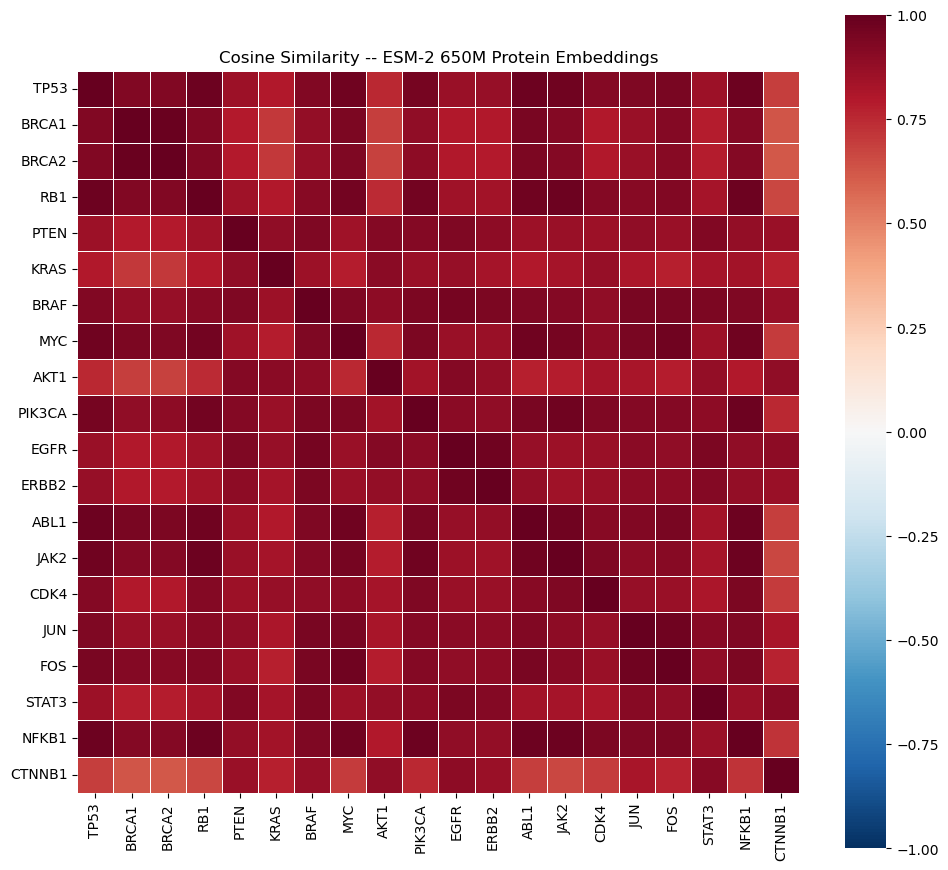

In [21]:
from embpy.tl.similarity import compute_similarity

cos_sim = compute_similarity(
    adata,
    obsm_key="X_esm2_650M",
    metric="cosine",
    plot=True,
    labels=list(adata.obs["gene"]),
    title="Cosine Similarity -- ESM-2 650M Protein Embeddings",
    figsize=(10, 9),
)

### 14b. UMAP Embedding Space Colored by Biological Annotations

UMAP projects the high-dimensional protein embeddings into 2D. We color
by functional category and subcellular location to check whether the PLM
captures these biological properties purely from amino acid sequence.

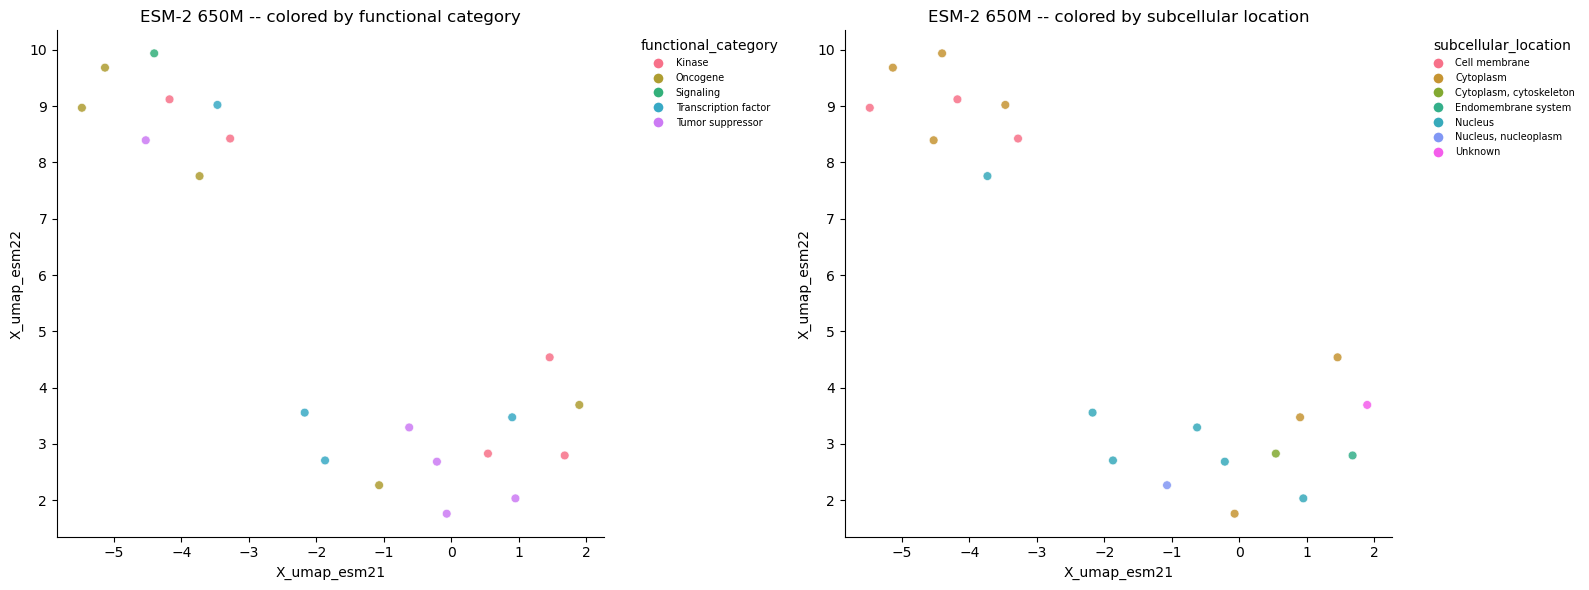

In [22]:
import embpy.pl as epl
import embpy.tl as etl
import matplotlib.pyplot as plt

etl.compute_umap(adata, obsm_key="X_esm2_650M", n_neighbors=5, output_key="X_umap_esm2")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epl.plot_embedding_space(
    adata,
    obsm_key="X_esm2_650M",
    basis="X_umap_esm2",
    color="functional_category",
    title="ESM-2 650M -- colored by functional category",
    ax=axes[0],
)

epl.plot_embedding_space(
    adata,
    obsm_key="X_esm2_650M",
    basis="X_umap_esm2",
    color="subcellular_location",
    title="ESM-2 650M -- colored by subcellular location",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

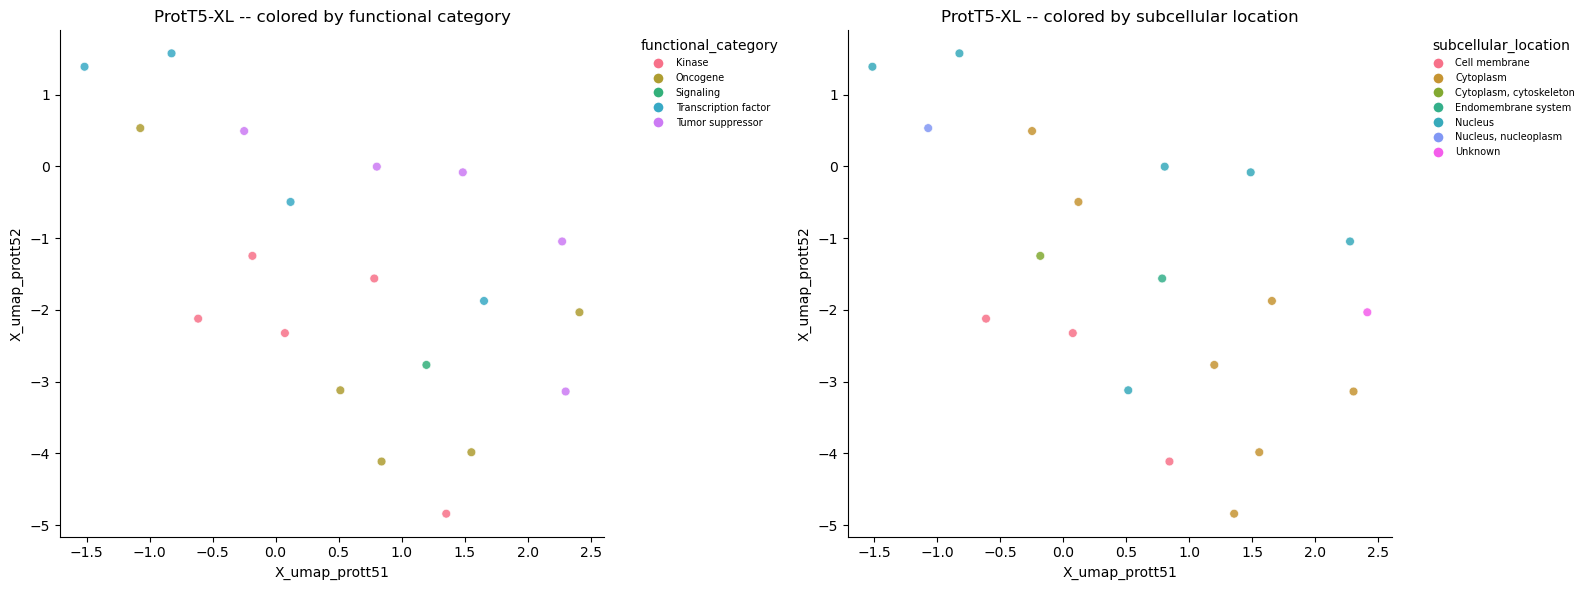

In [23]:
# UMAP for ProtT5 embeddings side-by-side
etl.compute_umap(adata, obsm_key="X_prot_t5_xl_half", n_neighbors=5, output_key="X_umap_prott5")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epl.plot_embedding_space(
    adata,
    obsm_key="X_prot_t5_xl_half",
    basis="X_umap_prott5",
    color="functional_category",
    title="ProtT5-XL -- colored by functional category",
    ax=axes[0],
)

epl.plot_embedding_space(
    adata,
    obsm_key="X_prot_t5_xl_half",
    basis="X_umap_prott5",
    color="subcellular_location",
    title="ProtT5-XL -- colored by subcellular location",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

### 14c. Cross-Model Similarity

How much do ESM-2 and ProtT5 agree on which proteins are similar? The
cross-model similarity heatmap computes pairwise cosine similarity within
each model and then correlates those similarity structures.

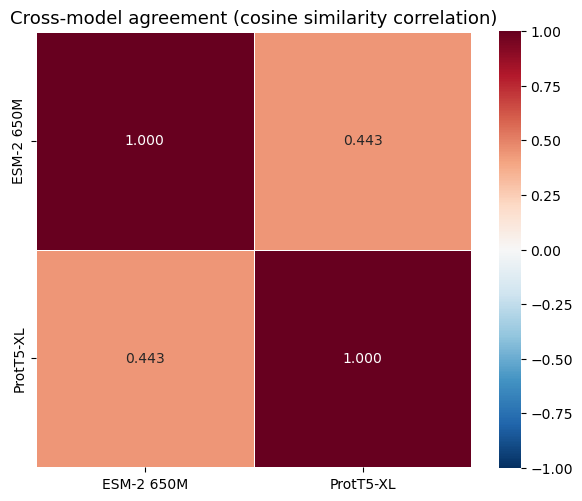

In [24]:
fig = epl.cross_model_similarity(
    adata,
    obsm_keys=["X_esm2_650M", "X_prot_t5_xl_half"],
    method="cosine_correlation",
    labels=["ESM-2 650M", "ProtT5-XL"],
    title="Cross-model agreement (cosine similarity correlation)",
    figsize=(6, 5),
)
plt.show()

### 14d. Hierarchical Clustering Dendrogram

The dendrogram reveals the hierarchical relationships between protein
embeddings. Proteins that share evolutionary or functional similarity
should merge at lower distances.

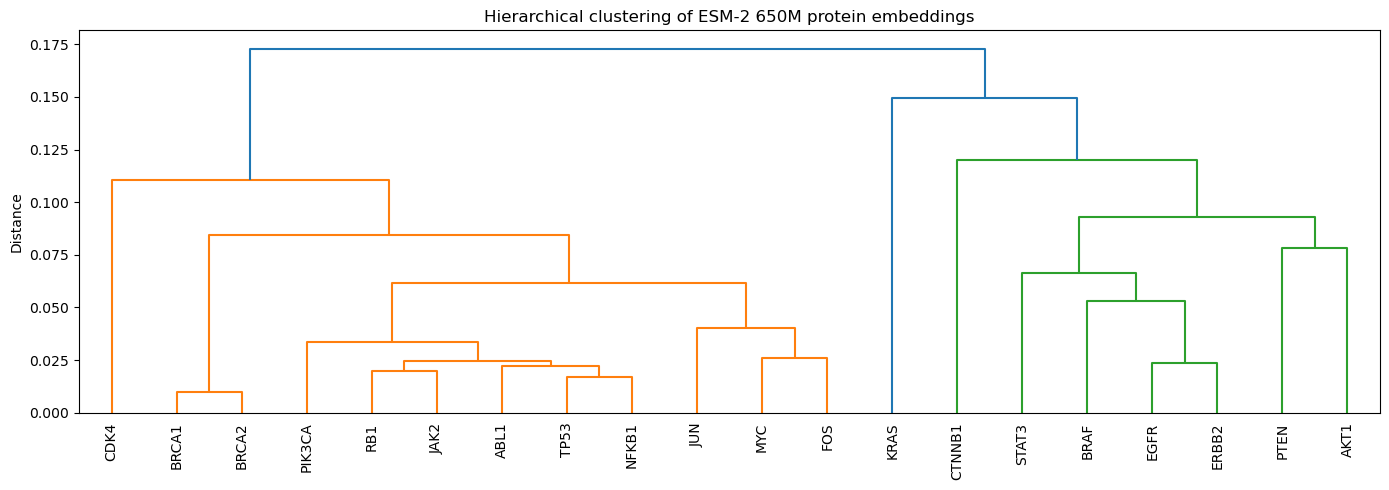

In [25]:
fig = epl.dendrogram(
    adata,
    obsm_key="X_esm2_650M",
    metric="cosine",
    labels=list(adata.obs["gene"]),
    title="Hierarchical clustering of ESM-2 650M protein embeddings",
    figsize=(14, 5),
    leaf_font_size=10,
)
plt.show()

### 14e. Embedding Distributions and Norms

Embedding distributions show how the values are distributed across
dimensions, while norms reveal whether the model assigns different
"magnitudes" to different proteins.

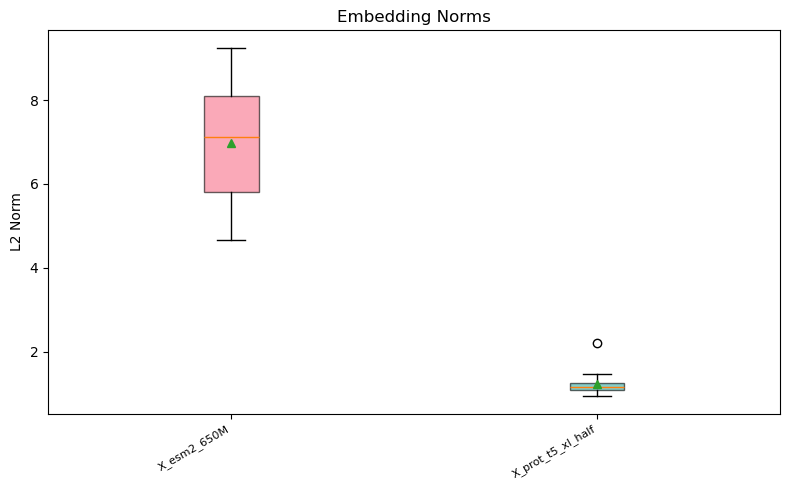

In [26]:
fig = epl.embedding_norms(
    adata,
    obsm_keys=["X_esm2_650M", "X_prot_t5_xl_half"],
)
plt.show()

### 14f. Embedding Clustermap

A clustermap jointly clusters proteins (rows) and embedding dimensions
(columns), revealing groups of co-varying features that correspond to
structural or functional motifs.

/ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/.pixi/envs/gpu/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/ictstr01/groups/ml01/workspace/goncalo.pinto/embpy/.pixi/envs/gpu/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


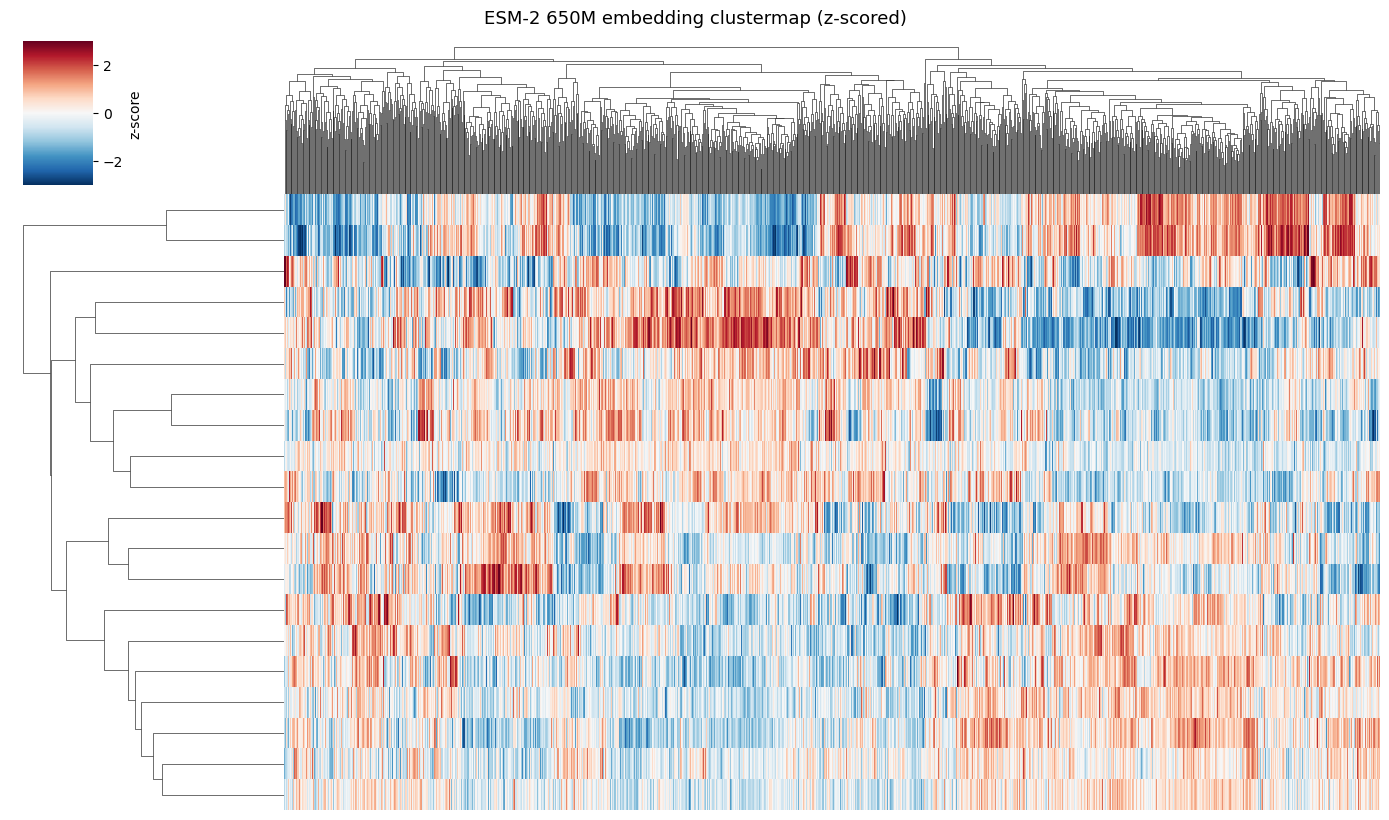

In [27]:
cg = epl.embedding_clustermap(
    adata,
    obsm_key="X_esm2_650M",
    n_obs=None,  # use all proteins
    z_score=True,
    title="ESM-2 650M embedding clustermap (z-scored)",
    figsize=(14, 8),
)
plt.show()

### 14g. Perturbation Ranking

Given a query protein, rank all others by embedding similarity. This is
useful for finding functionally related proteins.

In [28]:
from embpy.tl.similarity import rank_perturbations

# Which proteins are most similar to TP53 in ESM-2 embedding space?
ranking = rank_perturbations(
    adata,
    query="TP53",
    obsm_key="X_esm2_650M",
    top_k=10,
    metric="cosine",
)
print("Proteins most similar to TP53 (ESM-2 650M, cosine):\n")
for i, (gene_id, score) in enumerate(ranking, 1):
    cat = adata.obs.loc[gene_id, "functional_category"] if gene_id in adata.obs.index else "?"
    print(f"  {i:2d}. {gene_id:8s} (sim={score:.4f})  [{cat}]")

Proteins most similar to TP53 (ESM-2 650M, cosine):

   1. TP53     (sim=1.0000)  [Tumor suppressor]
   2. NFKB1    (sim=0.9829)  [Transcription factor]
   3. RB1      (sim=0.9783)  [Tumor suppressor]
   4. ABL1     (sim=0.9769)  [Kinase]
   5. MYC      (sim=0.9762)  [Oncogene]
   6. JAK2     (sim=0.9691)  [Kinase]
   7. PIK3CA   (sim=0.9602)  [Oncogene]
   8. FOS      (sim=0.9491)  [Transcription factor]
   9. JUN      (sim=0.9307)  [Transcription factor]
  10. BRCA1    (sim=0.9270)  [Tumor suppressor]


### 14h. Distance Heatmap

An alternative view using cosine distances instead of cosine similarity.

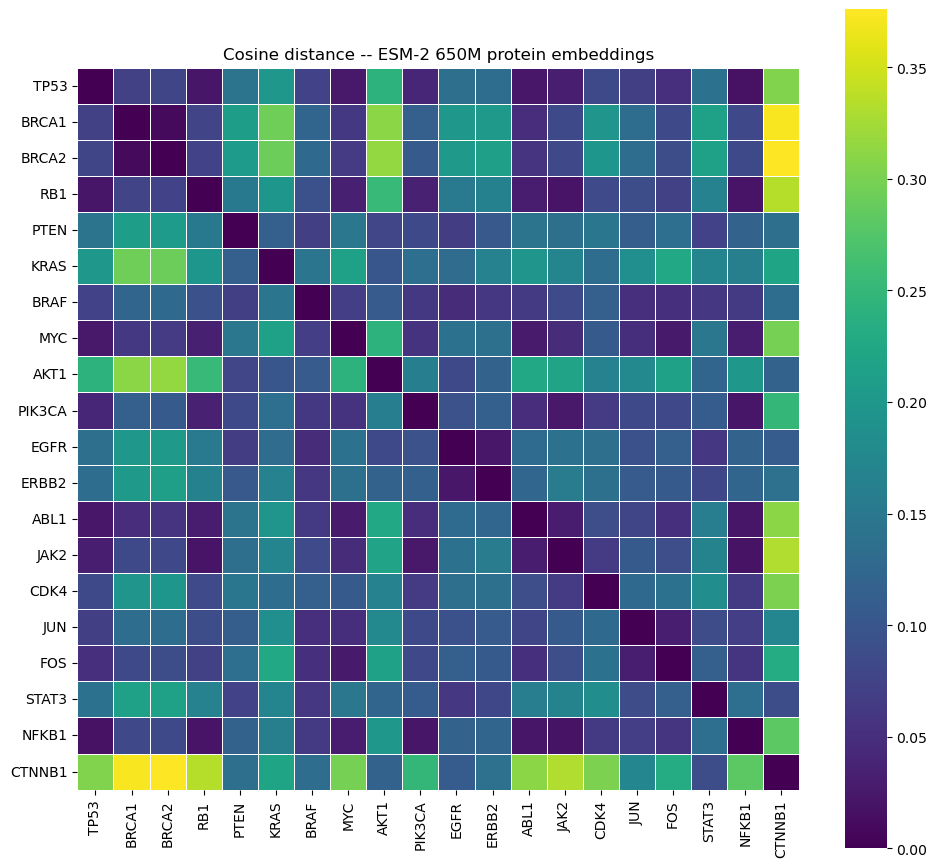

In [29]:
fig = epl.distance_heatmap(
    adata,
    obsm_key="X_esm2_650M",
    metric="cosine",
    labels=list(adata.obs["gene"]),
    title="Cosine distance -- ESM-2 650M protein embeddings",
    figsize=(10, 9),
)
plt.show()

## 15. Weighted Protein Embeddings

Standard protein embeddings treat every residue equally during pooling.
The `WeightedProteinEmbedder` offers three biologically-motivated
strategies that incorporate additional information:

| Strategy | What it does |
|---|---|
| `annotation_weighted` | Upweights residues at active/binding sites and motifs using UniProt annotations |
| `tpm_weighted` | Weights isoform embeddings by their expression levels (TPM) |
| `expression_context` | Concatenates the protein embedding with a tissue expression profile (e.g. from GTEx) |
| `full` | Returns all strategies in a single dict |

These produce more biologically-informed representations, particularly
useful for perturbation modeling where the effect of a gene knockout
depends on which isoform is expressed and which functional sites are
disrupted.

In [30]:
from embpy.tl.protein import WeightedProteinEmbedder

wpe = WeightedProteinEmbedder(embedder, organism="human")
MODEL = "esm2_650M"

# --- Annotation-weighted pooling ---
# Active sites and binding sites get 3x weight during mean pooling
emb_ann_weighted = wpe.annotation_weighted_embedding(
    "TP53",
    model=MODEL,
    weight_sites=["active_sites", "binding_sites", "motifs"],
    site_boost=3.0,
)
print(f"Annotation-weighted (TP53): shape {emb_ann_weighted.shape}, norm = {np.linalg.norm(emb_ann_weighted):.2f}")

# Compare with standard mean pooling
emb_standard = embedder.embed_protein("TP53", model=MODEL, pooling_strategy="mean")
cos = np.dot(emb_standard, emb_ann_weighted) / (np.linalg.norm(emb_standard) * np.linalg.norm(emb_ann_weighted))
print(f"Standard mean pooling:      shape {emb_standard.shape}, norm = {np.linalg.norm(emb_standard):.2f}")
print(f"\nCosine similarity (standard vs annotation-weighted): {cos:.4f}")
print(
    "  (high similarity means functional sites reinforce the overall signal;\n"
    "   lower similarity means they highlight distinct sequence features)"
)

Annotation-weighted (TP53): shape (1280,), norm = 8.38
Standard mean pooling:      shape (1280,), norm = 8.24

Cosine similarity (standard vs annotation-weighted): 0.9995
  (high similarity means functional sites reinforce the overall signal;
   lower similarity means they highlight distinct sequence features)


In [31]:
# --- TPM-weighted isoform averaging ---
# When no TPM values are provided, all isoforms are weighted equally
emb_tpm = wpe.tpm_weighted_embedding("TP53", model=MODEL)
print(f"TPM-weighted (equal weights): shape {emb_tpm.shape}, norm = {np.linalg.norm(emb_tpm):.2f}")

# With custom TPM values per isoform (simulating tissue-specific expression)
isoforms = embedder.protein_resolver.get_isoforms("TP53", id_type="symbol")
print(f"\nTP53 isoforms: {list(isoforms.keys())}")

# Simulate dominant isoform expression
if len(isoforms) > 1:
    iso_ids = list(isoforms.keys())
    tpm_sim = {iso_ids[0]: 100.0}  # dominant isoform
    for iso_id in iso_ids[1:]:
        tpm_sim[iso_id] = 1.0  # minor isoforms
    print(f"Simulated TPM: {tpm_sim}")

    emb_tpm_biased = wpe.tpm_weighted_embedding(
        "TP53",
        model=MODEL,
        tpm_values=tpm_sim,
    )
    cos_tpm = np.dot(emb_tpm, emb_tpm_biased) / (np.linalg.norm(emb_tpm) * np.linalg.norm(emb_tpm_biased))
    print(f"\nCosine similarity (equal vs biased TPM weights): {cos_tpm:.4f}")

TPM-weighted (equal weights): shape (1280,), norm = 8.24

TP53 isoforms: ['P04637']


In [32]:
# --- Expression-context embedding with GTEx ---
# Concatenates the protein embedding with a 54-dim tissue expression vector
emb_ctx = wpe.expression_context_embedding(
    "TP53",
    model=MODEL,
    use_gtex=True,
)
print(f"Expression-context (TP53 + GTEx): shape {emb_ctx.shape}")
print(f"  = {emb_standard.shape[0]} (protein) + {emb_ctx.shape[0] - emb_standard.shape[0]} (GTEx tissues)")
print(f"  norm = {np.linalg.norm(emb_ctx):.2f}")

Expression-context (TP53 + GTEx): shape (1334,)
  = 1280 (protein) + 54 (GTEx tissues)
  norm = 8.24


In [33]:
# --- Full strategy comparison for multiple genes ---
# embed_perturbation(strategy="full") returns all strategies at once

comparison_genes = ["TP53", "EGFR", "KRAS", "BRCA1"]

print("Full strategy comparison:\n")
for gene in comparison_genes:
    result = wpe.embed_perturbation(
        gene,
        model=MODEL,
        strategy="full",
        use_gtex=True,
    )
    print(f"  {gene}:")
    for strategy_name, emb in result.items():
        print(f"    {strategy_name:25s} -> dim {emb.shape[0]:,}, norm = {np.linalg.norm(emb):.2f}")
    print()

Full strategy comparison:

  TP53:
    canonical                 -> dim 1,280, norm = 8.24
    tpm_weighted              -> dim 1,280, norm = 8.24
    annotation_weighted       -> dim 1,280, norm = 8.38
    expression_context        -> dim 1,334, norm = 8.24

  EGFR:
    canonical                 -> dim 1,280, norm = 5.49
    tpm_weighted              -> dim 1,280, norm = 5.49
    annotation_weighted       -> dim 1,280, norm = 5.41
    expression_context        -> dim 1,334, norm = 5.50

  KRAS:
    canonical                 -> dim 1,280, norm = 5.03
    tpm_weighted              -> dim 1,280, norm = 5.03
    annotation_weighted       -> dim 1,280, norm = 4.74
    expression_context        -> dim 1,334, norm = 5.03

  BRCA1:
    canonical                 -> dim 1,280, norm = 9.14
    tpm_weighted              -> dim 1,280, norm = 9.14
    annotation_weighted       -> dim 1,280, norm = 9.14
    expression_context        -> dim 1,334, norm = 9.14



### Comparing weighted strategies in embedding space

How do different weighting strategies affect the relative positions of
proteins? We embed the same genes with canonical, annotation-weighted,
and TPM-weighted strategies and visualize them together.

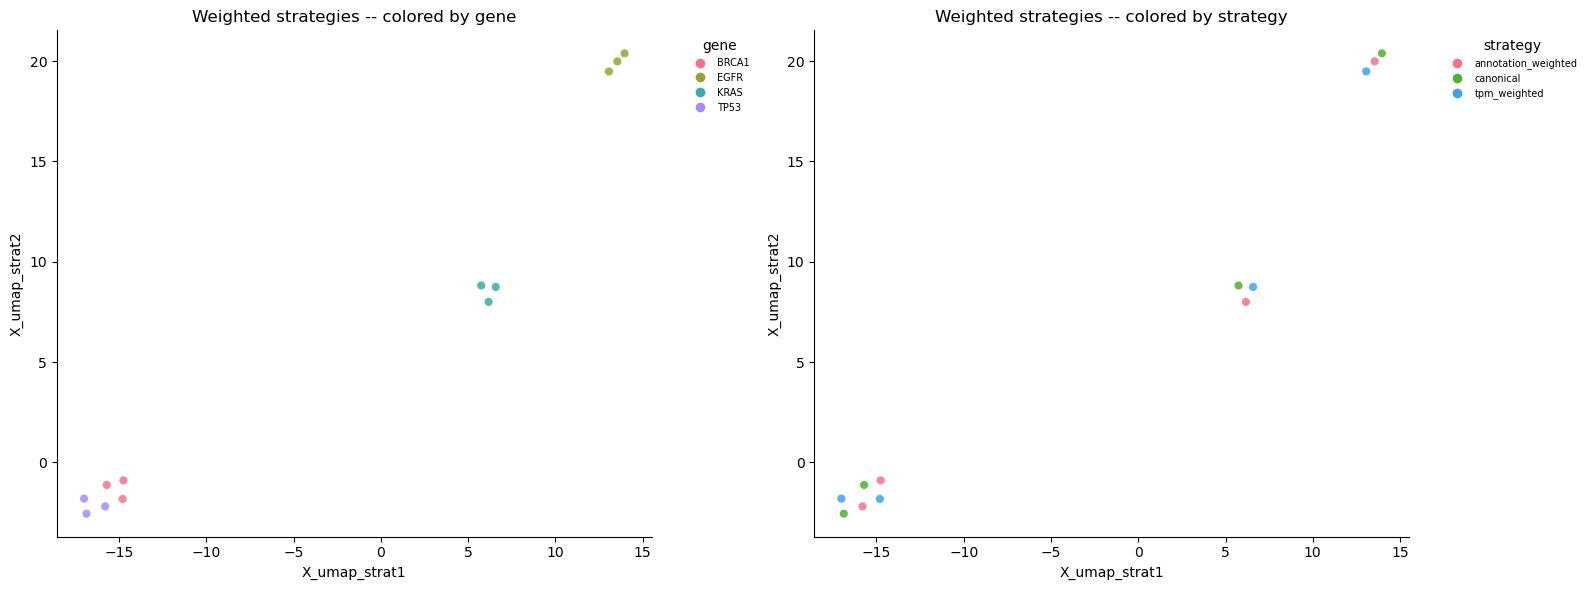


Interpretation:
  - Points for the same gene should cluster together (strategy shifts them slightly)
  - Annotation-weighted embeddings emphasize functional sites, potentially
    separating kinases from transcription factors more clearly


In [34]:
# Build a combined AnnData with all strategies for the comparison genes
strategies = ["canonical", "annotation_weighted", "tpm_weighted"]
rows = []
emb_list = []

for gene in comparison_genes:
    full = wpe.embed_perturbation(gene, model=MODEL, strategy="full")
    for strat in strategies:
        if strat in full:
            rows.append({"gene": gene, "strategy": strat, "label": f"{gene} ({strat})"})
            emb_list.append(full[strat])

obs_strat = pd.DataFrame(rows)
obs_strat.index = obs_strat["label"]
adata_strat = ad.AnnData(X=np.stack(emb_list), obs=obs_strat)
adata_strat.obsm["X_emb"] = adata_strat.X.copy()

etl.compute_umap(adata_strat, obsm_key="X_emb", n_neighbors=4, output_key="X_umap_strat")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epl.plot_embedding_space(
    adata_strat,
    obsm_key="X_emb",
    basis="X_umap_strat",
    color="gene",
    title="Weighted strategies -- colored by gene",
    ax=axes[0],
)

epl.plot_embedding_space(
    adata_strat,
    obsm_key="X_emb",
    basis="X_umap_strat",
    color="strategy",
    title="Weighted strategies -- colored by strategy",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Points for the same gene should cluster together (strategy shifts them slightly)")
print("  - Annotation-weighted embeddings emphasize functional sites, potentially")
print("    separating kinases from transcription factors more clearly")

## 16. Cross-Species Protein Comparison

Protein language models are trained on sequences from all kingdoms of
life. A natural question is: **do orthologous proteins from different
species cluster together in embedding space?** And does the embedding
distance correlate with evolutionary divergence?

`embpy` provides an `OrthologResolver` that uses Ensembl Compara to
automatically map gene symbols across species, and dedicated tools to
build cross-species AnnData objects and visualize evolutionary
conservation in embedding space.

### Species supported by `OrthologResolver`

human, mouse, rat, zebrafish, drosophila, worm, yeast, chicken, pig,
dog, macaque, chimpanzee, gorilla, cow, frog (and their Latin names).

### 16a. Resolving Orthologs with `OrthologResolver`

The resolver queries Ensembl Compara and returns structured results
including orthology type (one-to-one, one-to-many), sequence identity,
and Ensembl gene IDs for each target species.

In [35]:
from embpy.resources.protein import OrthologResolver

orth = OrthologResolver(source_species="human")

# Find orthologs of human TP53 in mouse and zebrafish
orthologs = orth.get_orthologs(
    "TP53",
    target_species=["mouse", "zebrafish"],
)
print(f"TP53 orthologs found: {len(orthologs)}\n")
for o in orthologs:
    print(f"  {o.target_symbol:12s} [{o.target_species}]  type={o.orthology_type}, identity={o.perc_id:.1f}%")

TP53 orthologs found: 2

  Trp53        [mus_musculus]  type=ortholog_one2one, identity=77.4%
  tp53         [danio_rerio]  type=ortholog_one2one, identity=47.8%


In [36]:
# Build a tabular ortholog mapping for multiple genes across species
cross_genes = ["TP53", "BRCA1", "EGFR", "KRAS", "MYC", "AKT1", "PTEN", "CDK4"]
target_species = ["mouse", "zebrafish", "drosophila"]

ortho_table = orth.get_ortholog_table(
    cross_genes,
    target_species=target_species,
    orthology_type="ortholog_one2one",
)
print("Ortholog mapping table (one-to-one):\n")
ortho_table

Ortholog mapping table (one-to-one):



,source_symbol,source_species,mus_symbol,mus_identity,mus_ensembl_id,danio_symbol,danio_identity,danio_ensembl_id,drosophila_symbol,drosophila_identity,drosophila_ensembl_id
0,TP53,homo_sapiens,Trp53,77.3537,ENSMUSG00000059552,tp53,47.8372,ENSDARG00000035559,None,NaN,None
1,BRCA1,homo_sapiens,Brca1,56.0923,ENSMUSG00000017146,None,NaN,None,None,NaN,None
2,EGFR,homo_sapiens,Egfr,90.4959,ENSMUSG00000020122,None,NaN,None,None,NaN,None
3,KRAS,homo_sapiens,Kras,90.4255,ENSMUSG00000030265,kras,88.2979,ENSDARG00000010844,None,NaN,None
4,MYC,homo_sapiens,Myc,90.0881,ENSMUSG00000022346,None,NaN,None,None,NaN,None
5,AKT1,homo_sapiens,Akt1,98.3333,ENSMUSG00000001729,None,NaN,None,None,NaN,None
6,PTEN,homo_sapiens,None,NaN,None,None,NaN,None,Pten,41.4392,FBgn0026379
7,CDK4,homo_sapiens,Cdk4,94.7195,ENSMUSG00000006728,cdk4,69.9670,ENSDARG00000087937,None,NaN,None


### 16b. Building a Cross-Species Embedding AnnData

`build_cross_species_adata` automates the full pipeline: resolve
orthologs, fetch protein sequences per species, embed them all with the
same PLM, and assemble into a single annotated AnnData.

In [37]:
from embpy.tl.protein import build_cross_species_adata

cross_genes = ["TP53", "BRCA1", "EGFR", "KRAS", "MYC", "PTEN", "AKT1", "CDK4"]
species = ["human", "mouse", "zebrafish"]

adata_cross = build_cross_species_adata(
    embedder,
    genes=cross_genes,
    species=species,
    model="esm2_650M",
    source_species="human",
    pooling_strategy="mean",
)

print(f"Cross-species AnnData: {adata_cross.shape}")
print(f"\nobs columns: {list(adata_cross.obs.columns)}")
print(f"\nSpecies distribution:\n{adata_cross.obs['species_short'].value_counts().to_string()}")
print(f"\nGene families: {adata_cross.obs['gene_family'].nunique()}")
print("\nSample rows:")
adata_cross.obs[["gene_family", "species_short", "symbol", "sequence_identity", "protein_length"]].head(12)

Cross-species AnnData: (16, 1280)

obs columns: ['gene_family', 'species', 'species_short', 'symbol', 'sequence_identity', 'protein_length']

Species distribution:
species_short
Homo     8
Mus      7
Danio    1

Gene families: 8

Sample rows:


,gene_family,species_short,symbol,sequence_identity,protein_length
TP53_Homo,TP53,Homo,TP53,100.0000,393
Trp53_Mus,TP53,Mus,Trp53,77.3537,390
tp53_Danio,TP53,Danio,tp53,47.8372,373
BRCA1_Homo,BRCA1,Homo,BRCA1,100.0000,1863
Brca1_Mus,BRCA1,Mus,Brca1,56.0923,1812
EGFR_Homo,EGFR,Homo,EGFR,100.0000,1210
Egfr_Mus,EGFR,Mus,Egfr,90.4959,1210
KRAS_Homo,KRAS,Homo,KRAS,100.0000,189
Kras_Mus,KRAS,Mus,Kras,90.4255,189
MYC_Homo,MYC,Homo,MYC,100.0000,454


### 16c. Cross-Species UMAP

Do orthologous proteins cluster by gene family (functional similarity)
or by species (evolutionary distance)? The UMAP answers this visually.

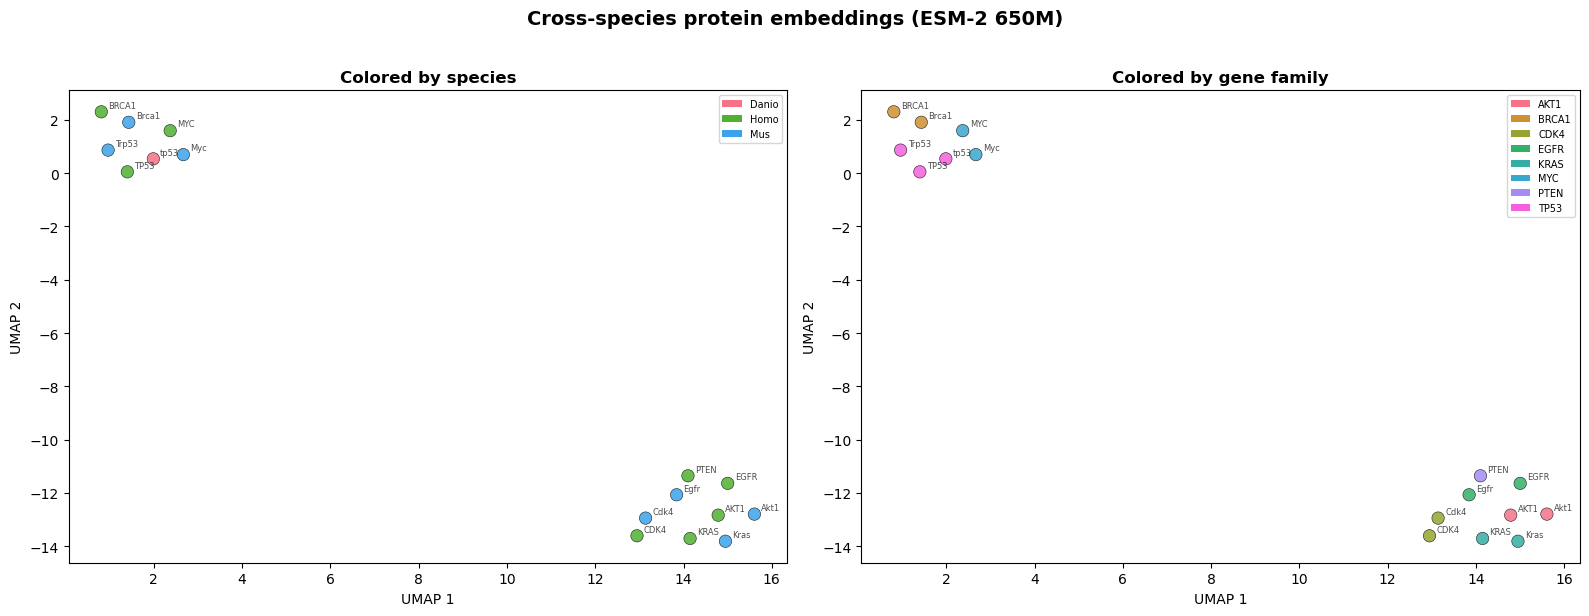

In [38]:
import embpy.pl as epl

fig = epl.plot_species_umap(
    adata_cross,
    obsm_key="X_emb",
    title="Cross-species protein embeddings (ESM-2 650M)",
)
plt.show()

### 16d. Cross-Species Similarity Heatmap

A clustered heatmap with row/column colors for gene family and species
shows which orthologs are most similar in embedding space.

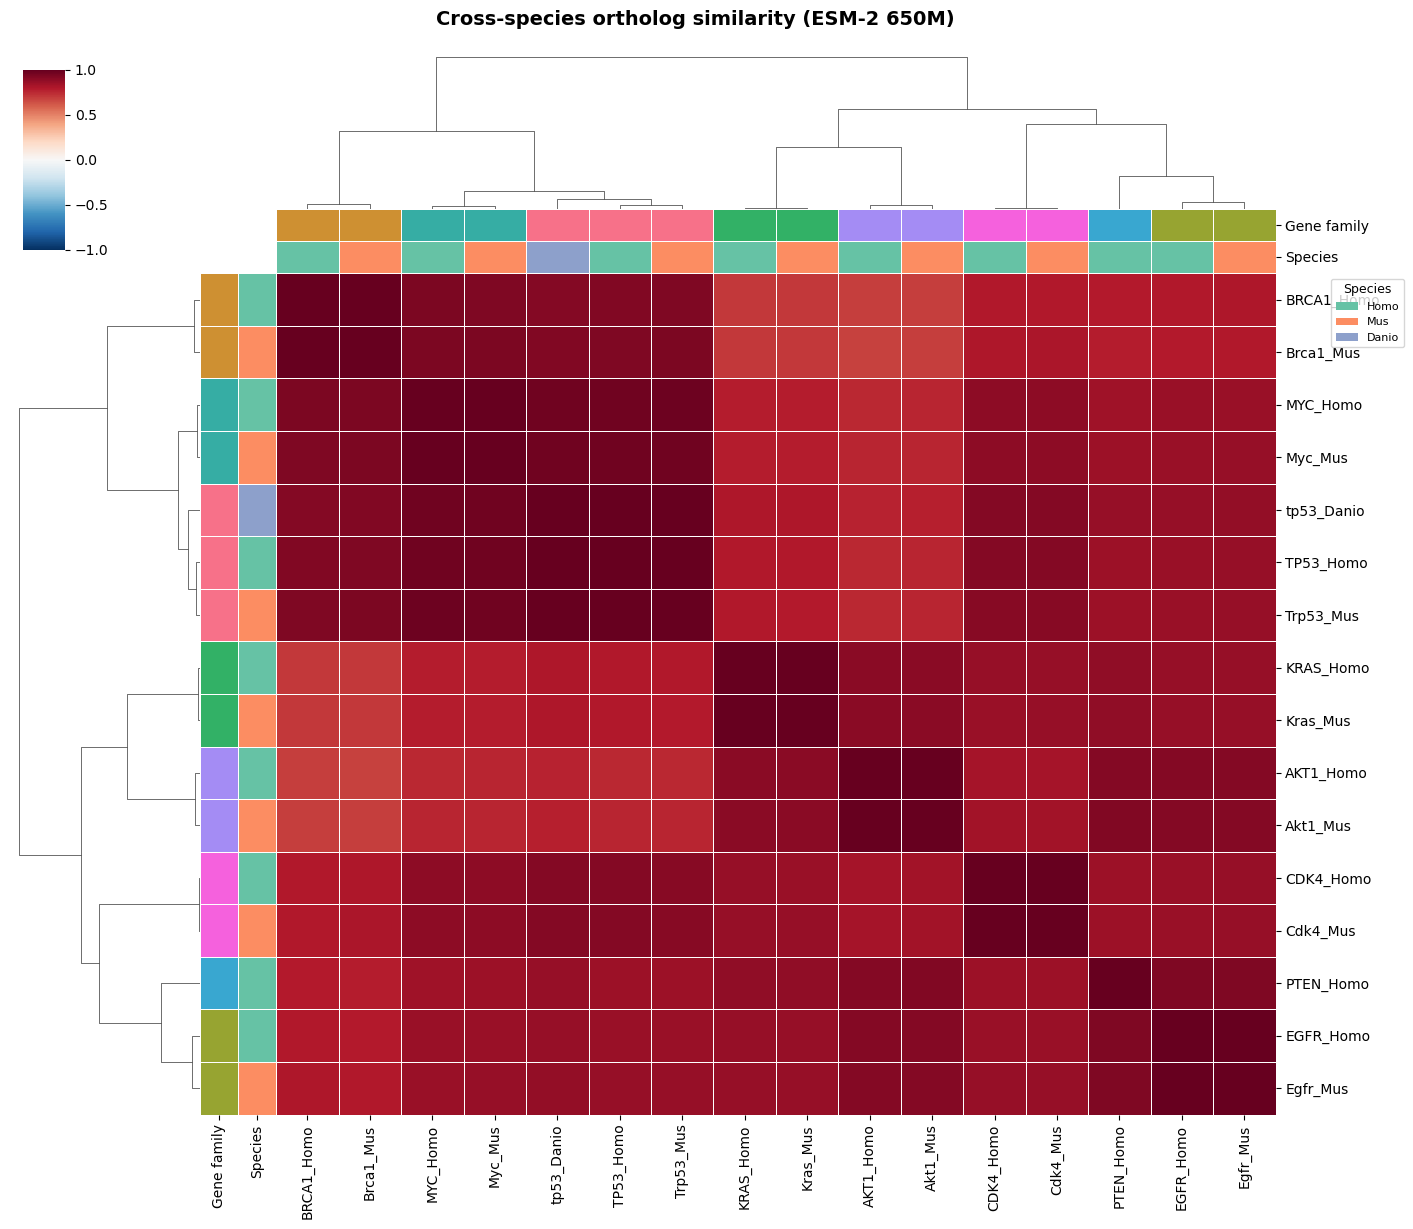

In [39]:
fig = epl.plot_ortholog_similarity(
    adata_cross,
    obsm_key="X_emb",
    title="Cross-species ortholog similarity (ESM-2 650M)",
    figsize=(14, 12),
)
plt.show()

### 16e. Sequence Identity vs. Embedding Similarity

The fundamental question: **does sequence conservation predict embedding
similarity?** If the PLM captures evolutionary relationships, we expect
a positive correlation between sequence identity (from Ensembl Compara)
and cosine similarity of embeddings.

Ortholog pairs analyzed: 9

gene_family species_a species_b  sequence_identity  embedding_similarity
       TP53      Homo       Mus            77.3537              0.998502
       TP53      Homo     Danio            47.8372              0.995857
       TP53       Mus     Danio            47.8372              0.995152
      BRCA1      Homo       Mus            56.0923              0.997692
       EGFR      Homo       Mus            90.4959              0.999217
       KRAS      Homo       Mus            90.4255              0.999887
        MYC      Homo       Mus            90.0881              0.999091
       AKT1      Homo       Mus            98.3333              0.999673
       CDK4      Homo       Mus            94.7195              0.999284


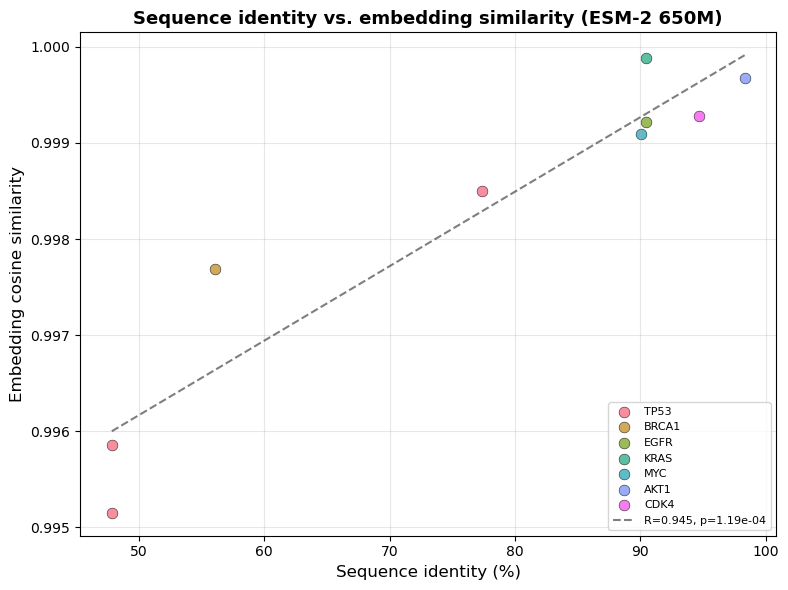

In [40]:
from embpy.tl.protein import identity_vs_similarity

id_sim_df = identity_vs_similarity(adata_cross, obsm_key="X_emb")

print(f"Ortholog pairs analyzed: {len(id_sim_df)}\n")
print(
    id_sim_df[["gene_family", "species_a", "species_b", "sequence_identity", "embedding_similarity"]].to_string(
        index=False
    )
)

fig = epl.plot_identity_vs_similarity(
    id_sim_df,
    title="Sequence identity vs. embedding similarity (ESM-2 650M)",
)
plt.show()

### 16f. Conservation Bar Plot

For each gene family, how similar is the mouse and zebrafish ortholog
embedding to the human reference? Highly conserved proteins (e.g.
histones, ribosomal) should show near 1.0 similarity across all species.

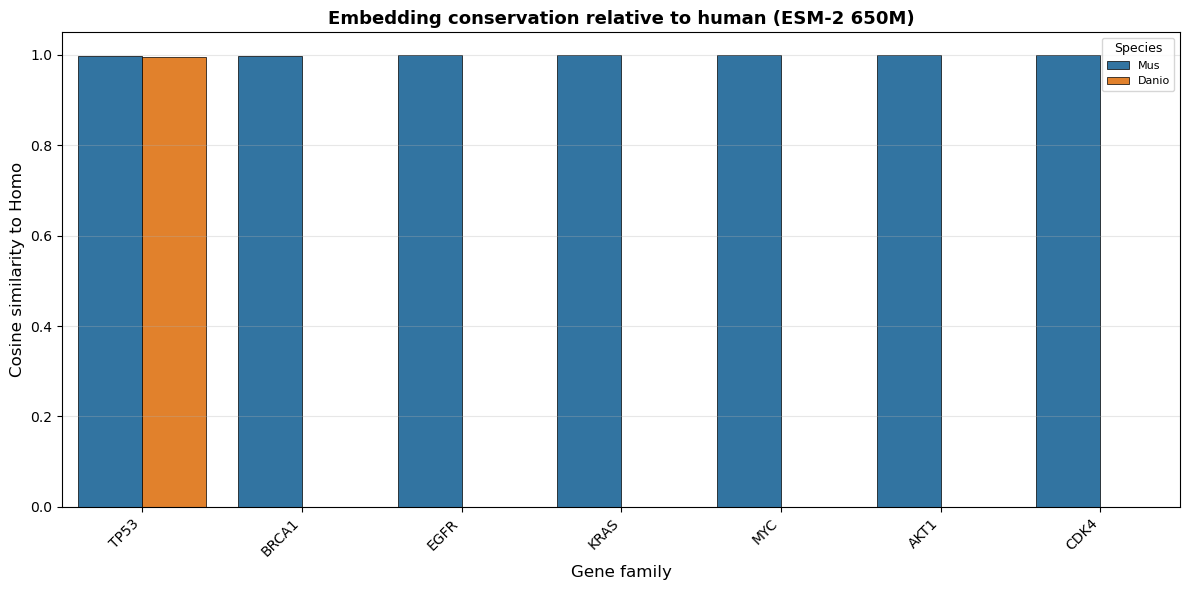

In [41]:
fig = epl.plot_conservation_barplot(
    adata_cross,
    obsm_key="X_emb",
    reference_species="Homo",
    title="Embedding conservation relative to human (ESM-2 650M)",
    figsize=(12, 6),
)
plt.show()

### 16g. Cross-Species Dendrogram

Hierarchical clustering of the cross-species embeddings. Orthologs of
the same gene should cluster together (indicating the PLM captures
gene identity across species), while within each cluster the branching
pattern should reflect the species phylogeny.

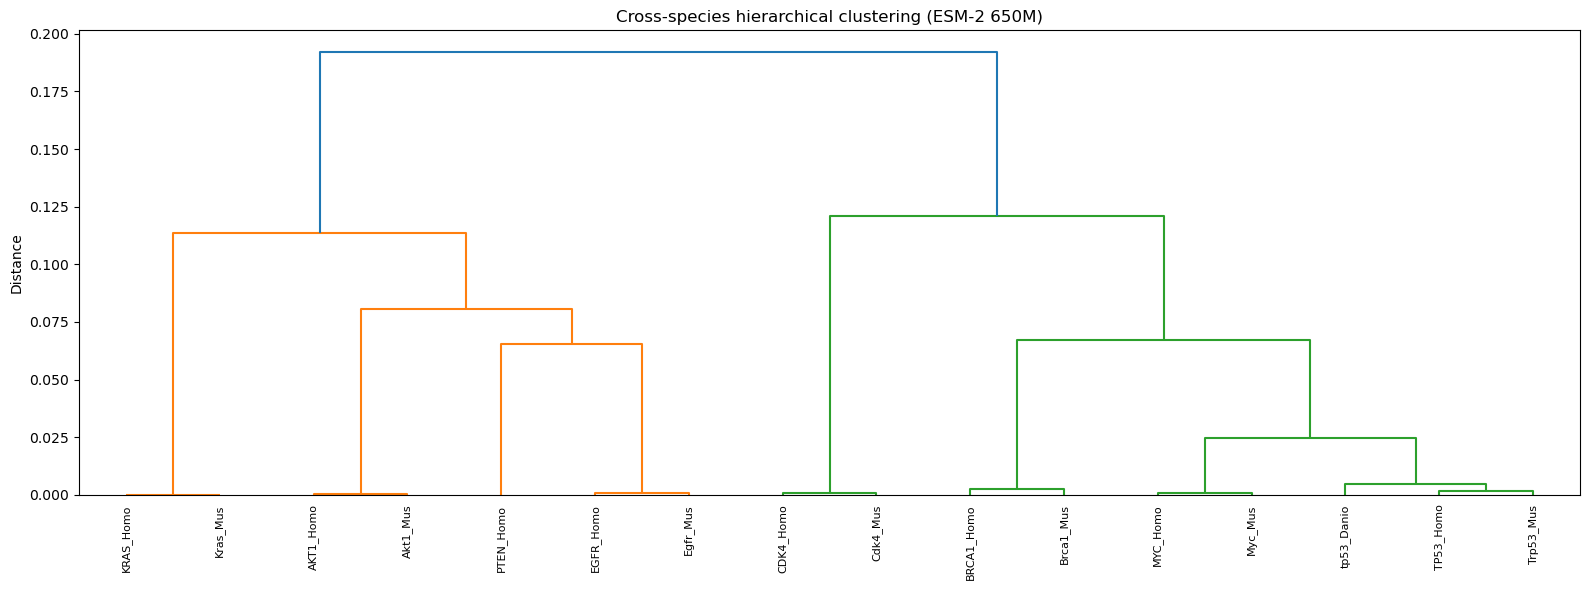


Interpretation:
  - Orthologs of the same gene (e.g. TP53_Homo, Trp53_Mus, tp53_Danio)
    should form tight subclusters.
  - Within each gene cluster, branching should reflect the species tree
    (human-mouse closer than human-zebrafish).


In [42]:
fig = epl.dendrogram(
    adata_cross,
    obsm_key="X_emb",
    metric="cosine",
    labels=list(adata_cross.obs.index),
    title="Cross-species hierarchical clustering (ESM-2 650M)",
    figsize=(16, 6),
    leaf_font_size=8,
)
plt.show()

print("\nInterpretation:")
print("  - Orthologs of the same gene (e.g. TP53_Homo, Trp53_Mus, tp53_Danio)")
print("    should form tight subclusters.")
print("  - Within each gene cluster, branching should reflect the species tree")
print("    (human-mouse closer than human-zebrafish).")

## Summary

### Embedding

| What | How |
|---|---|
| Protein embedding by gene symbol | `embed_gene("TP53", model="esm2_650M")` |
| Protein embedding by raw sequence | `embed_gene("MTEYKLV...", model="esm2_650M")` |
| Canonical protein embedding | `embed_protein("TP53", model, isoform="canonical")` |
| All isoform embeddings | `embed_protein("TP53", model, isoform="all")` |
| Batch canonical | `embed_proteins_batch(genes, model, isoform="canonical")` |
| Batch all isoforms | `embed_proteins_batch(genes, model, isoform="all")` |
| ProtT5 embedding | `embed_protein("TP53", model="prot_t5_xl_half")` |
| Boltz-2 structure embedding | `embed_protein("TP53", model="boltz2")` |

### Annotation

| What | How |
|---|---|
| Full protein annotations | `ProteinAnnotator().annotate("TP53")` |
| Selective annotations | `pa.annotate("TP53", sources=["domains", "go", "ptms"])` |
| Batch annotation | `pa.annotate_batch(["TP53", "BRCA1"])` |
| Annotate AnnData | `pa.annotate_adata(adata, column="gene")` |
| InterPro domains | `pa.get_interpro_domains(accession)` |

### Resolution

| What | How |
|---|---|
| Resolve UniProt ID | `ProteinResolver().resolve_uniprot_id("TP53")` |
| Fetch canonical sequence | `ProteinResolver().get_canonical_sequence("TP53")` |
| Fetch all isoforms | `ProteinResolver().get_isoforms("TP53")` |
| Download full proteome | `ProteinResolver().download_proteome()` |

### Cross-Species

| What | How |
|---|---|
| Resolve orthologs | `OrthologResolver().get_orthologs("TP53", target_species=["mouse"])` |
| Ortholog mapping table | `orth.get_ortholog_table(genes, target_species=[...])` |
| Cross-species AnnData | `build_cross_species_adata(embedder, genes, species, model)` |
| Seq. identity vs. similarity | `identity_vs_similarity(adata)` |
| Cross-species UMAP | `epl.plot_species_umap(adata)` |
| Ortholog similarity heatmap | `epl.plot_ortholog_similarity(adata)` |
| Identity-similarity scatter | `epl.plot_identity_vs_similarity(df)` |
| Conservation bar plot | `epl.plot_conservation_barplot(adata)` |

### Weighted Embeddings

| What | How |
|---|---|
| Annotation-weighted pooling | `WeightedProteinEmbedder(embedder).annotation_weighted_embedding("TP53", model)` |
| TPM-weighted isoform avg. | `wpe.tpm_weighted_embedding("TP53", model, tpm_values={...})` |
| Expression-context (GTEx) | `wpe.expression_context_embedding("TP53", model, use_gtex=True)` |
| All strategies at once | `wpe.embed_perturbation("TP53", model, strategy="full")` |

### Visualization

| What | How |
|---|---|
| Similarity heatmap | `compute_similarity(adata, obsm_key, plot=True)` |
| UMAP embedding space | `epl.plot_embedding_space(adata, color="functional_category")` |
| Cross-model agreement | `epl.cross_model_similarity(adata, obsm_keys=[...])` |
| Dendrogram | `epl.dendrogram(adata, obsm_key)` |
| Embedding norms | `epl.embedding_norms(adata, obsm_keys=[...])` |
| Embedding clustermap | `epl.embedding_clustermap(adata, obsm_key)` |
| Distance heatmap | `epl.distance_heatmap(adata, obsm_key)` |
| Perturbation ranking | `rank_perturbations(adata, query="TP53", obsm_key)` |

Next: [Tutorial 4 -- Boltz-2 Structure Embeddings](04_boltz2_structure_embeddings.ipynb)